In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
df = pd.read_csv(r"C:/Users/lenovo/Downloads/airline_passengers.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    145 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


In [121]:
df=df.iloc[:-1]

In [122]:
df['Date'] = pd.to_datetime(df.Month,format = '%Y-%m')

In [123]:
df.set_index('Date',inplace=True)

In [124]:
df=df.drop(columns='Month')
df.head(10)

,Thousands of Passengers
Date,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
1949-06-01,135.0
1949-07-01,148.0
1949-08-01,148.0
1949-09-01,136.0


<Axes: xlabel='Date'>

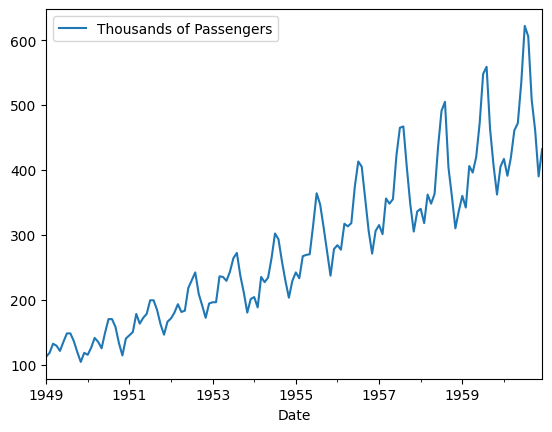

In [125]:
%matplotlib inline
df.plot()

In [126]:
from statsmodels.tsa.stattools import adfuller

In [127]:
def adf_test(x):
    result = adfuller(x)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [128]:
c = adf_test(df)
c

ADF Statistics: 0.8153688792060497
p- value: 0.991880243437641
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [130]:
df['first shift']= df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(1)

In [131]:
df['first shift']

Date
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: first shift, Length: 144, dtype: float64

In [132]:
adf_test(df['first shift'].dropna())

ADF Statistics: -2.829266824169991
p- value: 0.054213290283826696
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [133]:
df['second shift'] = df['first shift']-df['first shift'].shift(1)

In [134]:
adf_test(df['second shift'].dropna())

ADF Statistics: -16.384231542468516
p- value: 2.7328918500141235e-29
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


<Axes: xlabel='Date'>

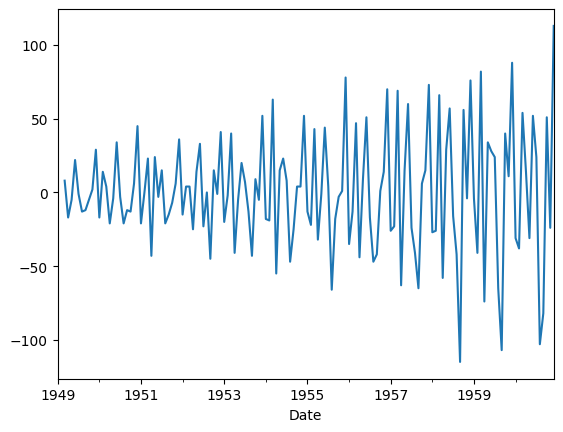

In [135]:
df['second shift'].plot()

In [136]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

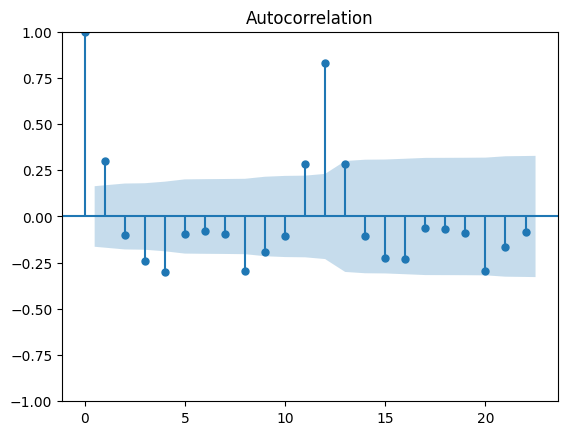

In [137]:
acf = plot_acf(df['first shift'].dropna())

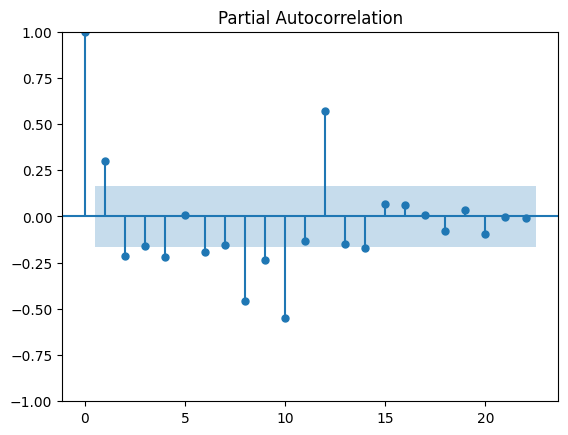

In [138]:
pacf = plot_pacf(df['first shift'].dropna())

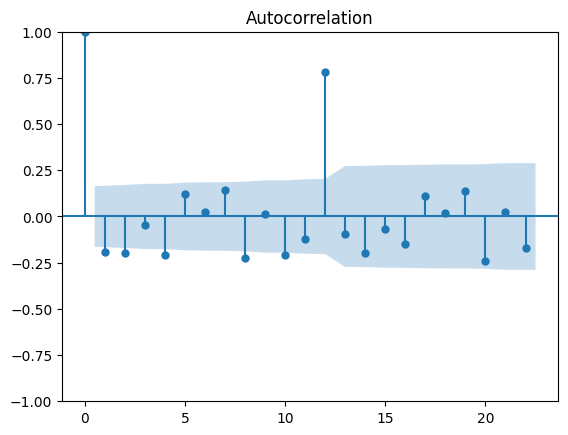

In [139]:
acf = plot_acf(df['second shift'].dropna())

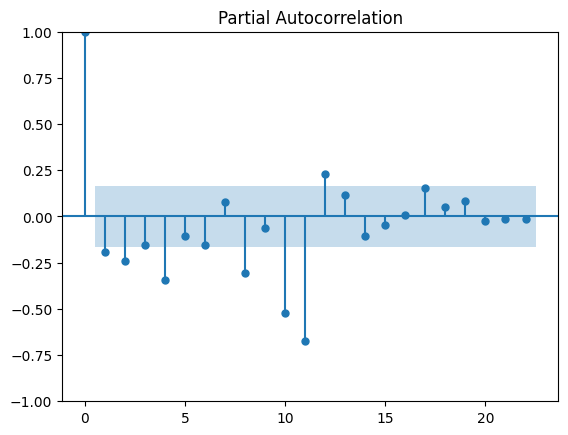

In [140]:
pacf = plot_pacf(df['second shift'].dropna())

In [143]:
df['12 shift'] = df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(12)

In [144]:
adf_test(df['12 shift'].dropna())

ADF Statistics: -3.3830207264924805
p- value: 0.011551493085514982
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


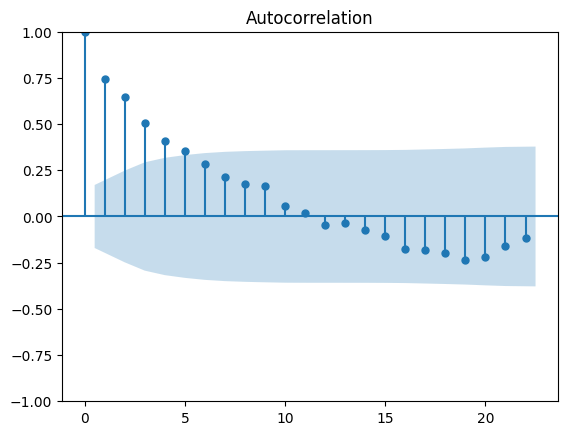

In [145]:
acf = plot_acf(df['12 shift'].dropna())

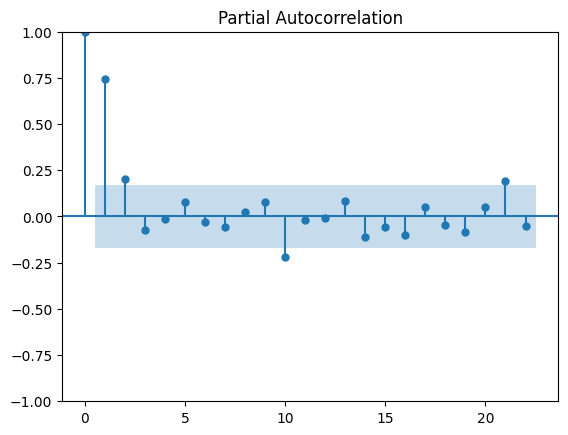

In [146]:
pacf = plot_pacf(df['12 shift'].dropna())

In [157]:
from statsmodels.tsa.arima.model import ARIMA

In [158]:
from datetime import datetime,timedelta
train_dataset_end=datetime(1955,12,1)
test_dataset_end=datetime(1960,12,1)

In [159]:
train_data = df[:train_dataset_end]
test_data = df[train_dataset_end+timedelta(days=1):test_dataset_end]

In [160]:
train_data

,Thousands of Passengers,first shift,second shift,12 shift
Date,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1955-08-01,347.0,-17.0,-66.0,54.0
1955-09-01,312.0,-35.0,-18.0,53.0
1955-10-01,274.0,-38.0,-3.0,45.0


In [161]:
arima_ = ARIMA(train_data['Thousands of Passengers'],order=(0,2,0))

e:\code\datascience\plot\.venv\ml\ML_Prog\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [169]:
fits = arima_.fit()
fits.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                      ARIMA(0, 2, 0)   Log Likelihood                -385.792
Date:                     Fri, 12 Jun 2026   AIC                            773.584
Time:                             00:19:36   BIC                            775.991
Sample:                         01-01-1949   HQIC                           774.550
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       714.5859    102.414      6.977      0.000     513.858     915.314
===================================================================================
Ljung-Box (L1) (Q):                   4.59   Jarque-Bera (JB):                 1.74
Prob(Q):                              0.03   Prob(JB):                         0.42
Heteroskedasticity (H):               3.19   Skew:                             0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [171]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [172]:
pred = fits.predict(start=pred_start_date,end=pred_end_date)

In [173]:
test_data['pred'] = pred

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3080\1795025050.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['pred'] = pred


In [175]:
devation = test_data['Thousands of Passengers'] - pred
test_data

,Thousands of Passengers,first shift,second shift,12 shift,pred
Date,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,319.0
1956-02-01,277.0,-7.0,-13.0,44.0,360.0
1956-03-01,317.0,40.0,47.0,50.0,401.0
1956-04-01,313.0,-4.0,-44.0,44.0,442.0
1956-05-01,318.0,5.0,9.0,48.0,483.0
1956-06-01,374.0,56.0,51.0,59.0,524.0
1956-07-01,413.0,39.0,-17.0,49.0,565.0
1956-08-01,405.0,-8.0,-47.0,58.0,606.0
1956-09-01,355.0,-50.0,-42.0,43.0,647.0


<Axes: xlabel='Date'>

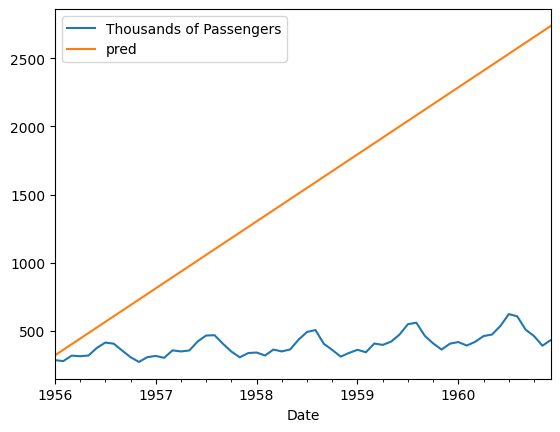

In [168]:
test_data[['Thousands of Passengers','pred']].plot()